In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Libraries imported!")

✅ Libraries imported!


In [6]:
# LOAD DATA FROM PART 1
# ============================================
file_path = r"C:\Users\hunda\OneDrive\Desktop\Syracuse\Masters\Sem 2\IST 707 Applied Machine Learning\ML\group-project-avengers\data\processed\taxi_features.parquet"

print("📂 Loading Part 1 feature-engineered data...")
df = pd.read_parquet(file_path)
print(f"✅ Loaded {len(df):,} trips with {len(df.columns)} columns")

original_col_count = len(df.columns)

📂 Loading Part 1 feature-engineered data...
✅ Loaded 2,451,103 trips with 32 columns


In [7]:
# ============================================
# LOAD RAW DATA (for missing value indicators)
# ============================================
raw_path = r"C:\Users\hunda\OneDrive\Desktop\Syracuse\Masters\Sem 2\IST 707 Applied Machine Learning\ML\group-project-avengers\data\raw\yellow_tripdata_2025-01.parquet"
print("📂 Loading raw data for missing value analysis...")
df_raw = pd.read_parquet(raw_path)
print(f"✅ Raw data loaded: {len(df_raw):,} trips")

📂 Loading raw data for missing value analysis...
✅ Raw data loaded: 3,475,226 trips


In [8]:
# ============================================================
#         SECTION 1: MISSING VALUE INDICATORS
# ============================================================
print("\n" + "="*70)
print("SECTION 1: MISSING VALUE INDICATORS")
print("="*70)

# Show missing value patterns from RAW data
print("Missing values in RAW data (before cleaning):")
raw_missing_cols = ['passenger_count', 'RatecodeID', 'store_and_fwd_flag',
                    'congestion_surcharge', 'Airport_fee']
for col in raw_missing_cols:
    count = df_raw[col].isnull().sum()
    pct = count / len(df_raw) * 100
    print(f"   {col}: {count:,} missing ({pct:.1f}%)")

# Create indicators in cleaned data
# All 0 since cleaning removed rows with missing values,
# but documents that missing data was considered
df['has_missing_passenger_count'] = 0
df['has_missing_ratecode'] = 0
df['has_missing_store_fwd'] = 0
df['has_missing_congestion_surcharge'] = 0
df['has_missing_airport_fee'] = 0

# Free raw data from memory
del df_raw

print(f"\n✅ Missing value indicators created (5 columns)")
print(f"   All values are 0 in cleaned data since rows with")
print(f"   missing values were removed during data cleaning.")


SECTION 1: MISSING VALUE INDICATORS
Missing values in RAW data (before cleaning):
   passenger_count: 540,149 missing (15.5%)
   RatecodeID: 540,149 missing (15.5%)
   store_and_fwd_flag: 540,149 missing (15.5%)
   congestion_surcharge: 540,149 missing (15.5%)
   Airport_fee: 540,149 missing (15.5%)

✅ Missing value indicators created (5 columns)
   All values are 0 in cleaned data since rows with
   missing values were removed during data cleaning.


In [9]:
# ============================================================
#        SECTION 2: STORE AND FORWARD ENCODING
# ============================================================
print("\n" + "="*70)
print("SECTION 2: STORE AND FORWARD FLAG ENCODING")
print("="*70)

print(f"store_and_fwd_flag values:")
print(df['store_and_fwd_flag'].value_counts(dropna=False))

# Handle missing values - fill with 'N' (most common)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')

# Encode: Y=1 (trip data stored then forwarded), N=0 (sent directly)
df['store_and_fwd_encoded'] = (df['store_and_fwd_flag'] == 'Y').astype(int)

print(f"\n✅ store_and_fwd_encoded created:")
print(f"   0 (direct): {(df['store_and_fwd_encoded'] == 0).sum():,}")
print(f"   1 (stored): {(df['store_and_fwd_encoded'] == 1).sum():,}")


SECTION 2: STORE AND FORWARD FLAG ENCODING
store_and_fwd_flag values:
store_and_fwd_flag
N    2444976
Y       6127
Name: count, dtype: int64

✅ store_and_fwd_encoded created:
   0 (direct): 2,444,976
   1 (stored): 6,127


In [10]:
# ============================================================
#          SECTION 3: CATEGORICAL ENCODINGS
# ============================================================
print("\n" + "="*70)
print("SECTION 3: CATEGORICAL ENCODINGS")
print("="*70)

# --- 3A: PAYMENT TYPE ---
print("\n--- 3A: Payment Type One-Hot Encoding ---")
print(f"Unique values: {sorted(df['payment_type'].unique())}")

payment_map = {1: 'credit', 2: 'cash', 3: 'no_charge', 4: 'dispute', 5: 'unknown', 6: 'voided'}
df['payment_name'] = df['payment_type'].map(payment_map).fillna('other')

print("Distribution:")
print(df['payment_name'].value_counts().to_string())

payment_dummies = pd.get_dummies(df['payment_name'], prefix='pay', dtype=int)
df = pd.concat([df, payment_dummies], axis=1)
print(f"✅ Columns created: {list(payment_dummies.columns)}")

# --- 3B: VENDOR ID ---
print("\n--- 3B: VendorID One-Hot Encoding ---")
print(f"Unique values: {sorted(df['VendorID'].unique())}")
print("Distribution:")
print(df['VendorID'].value_counts().sort_index().to_string())

vendor_dummies = pd.get_dummies(df['VendorID'], prefix='vendor', dtype=int)
df = pd.concat([df, vendor_dummies], axis=1)
print(f"✅ Columns created: {list(vendor_dummies.columns)}")

# --- 3C: RATECODE ID ---
print("\n--- 3C: RatecodeID One-Hot Encoding ---")

# Handle missing values
missing_rate = df['RatecodeID'].isnull().sum()
if missing_rate > 0:
    df['RatecodeID'] = df['RatecodeID'].fillna(1.0)
    print(f"   Filled {missing_rate:,} missing with 1 (Standard rate)")

print(f"Unique values: {sorted(df['RatecodeID'].unique())}")

ratecode_map = {1: 'standard', 2: 'jfk', 3: 'newark', 4: 'nassau', 5: 'negotiated', 6: 'group'}
df['ratecode_name'] = df['RatecodeID'].map(ratecode_map).fillna('other')

print("Distribution:")
print(df['ratecode_name'].value_counts().to_string())

ratecode_dummies = pd.get_dummies(df['ratecode_name'], prefix='rate', dtype=int)
df = pd.concat([df, ratecode_dummies], axis=1)
print(f"✅ Columns created: {list(ratecode_dummies.columns)}")


SECTION 3: CATEGORICAL ENCODINGS

--- 3A: Payment Type One-Hot Encoding ---
Unique values: [1, 2, 3, 4]
Distribution:
payment_name
credit       2107950
cash          304467
dispute        29251
no_charge       9435
✅ Columns created: ['pay_cash', 'pay_credit', 'pay_dispute', 'pay_no_charge']

--- 3B: VendorID One-Hot Encoding ---
Unique values: [1, 2]
Distribution:
VendorID
1     526435
2    1924668
✅ Columns created: ['vendor_1', 'vendor_2']

--- 3C: RatecodeID One-Hot Encoding ---
Unique values: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
Distribution:
ratecode_name
standard      2355933
jfk             73680
negotiated       9944
newark           5930
nassau           5615
group               1
✅ Columns created: ['rate_group', 'rate_jfk', 'rate_nassau', 'rate_negotiated', 'rate_newark', 'rate_standard']


In [11]:
# ============================================================
#           SECTION 4: INTERACTION FEATURES
# ============================================================
print("\n" + "="*70)
print("SECTION 4: INTERACTION FEATURES")
print("="*70)

# Extract hour and day of week (needed for interactions)
if 'pickup_hour' not in df.columns:
    df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
if 'pickup_dayofweek' not in df.columns:
    df['pickup_dayofweek'] = df['tpep_pickup_datetime'].dt.dayofweek

# --- 4A: Distance × Passenger Count ---
df['distance_x_passengers'] = df['trip_distance'] * df['passenger_count']

# --- 4B: Fare × Payment Type ---
df['fare_x_credit'] = df['fare_amount'] * (df['payment_type'] == 1).astype(int)
df['fare_x_cash'] = df['fare_amount'] * (df['payment_type'] == 2).astype(int)

# --- 4C: Hour × Day of Week ---
df['hour_x_dayofweek'] = df['pickup_hour'] * df['pickup_dayofweek']

# Unique time slot (168 possible: 24 hours × 7 days)
df['time_slot'] = df['pickup_dayofweek'] * 24 + df['pickup_hour']

print("✅ Interaction features created:")
print(f"   distance_x_passengers: Mean={df['distance_x_passengers'].mean():.2f}")
print(f"   fare_x_credit:        Mean=${df['fare_x_credit'].mean():.2f}")
print(f"   fare_x_cash:          Mean=${df['fare_x_cash'].mean():.2f}")
print(f"   hour_x_dayofweek:     Range={df['hour_x_dayofweek'].min():.0f} to {df['hour_x_dayofweek'].max():.0f}")
print(f"   time_slot:            Range={df['time_slot'].min():.0f} to {df['time_slot'].max():.0f} (168 possible)")


SECTION 4: INTERACTION FEATURES
✅ Interaction features created:
   distance_x_passengers: Mean=4.06
   fare_x_credit:        Mean=$14.92
   fare_x_cash:          Mean=$2.20
   hour_x_dayofweek:     Range=0 to 138
   time_slot:            Range=0 to 167 (168 possible)


In [12]:
# ============================================================
#       SECTION 5: FARE COMPONENT INTERACTIONS
# ============================================================
print("\n" + "="*70)
print("SECTION 5: FARE COMPONENT INTERACTIONS")
print("="*70)

# Congestion surcharge as % of total
df['congestion_surcharge_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['congestion_surcharge'] / df['total_amount']) * 100, 0
)
df['congestion_surcharge_ratio'] = df['congestion_surcharge_ratio'].clip(0, 100)

# Airport fee as % of total
df['airport_fee_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['Airport_fee'] / df['total_amount']) * 100, 0
)
df['airport_fee_ratio'] = df['airport_fee_ratio'].clip(0, 100)

# MTA tax as % of total
df['mta_tax_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['mta_tax'] / df['total_amount']) * 100, 0
)
df['mta_tax_ratio'] = df['mta_tax_ratio'].clip(0, 100)

# CBD congestion fee as % of total
df['cbd_fee_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['cbd_congestion_fee'] / df['total_amount']) * 100, 0
)
df['cbd_fee_ratio'] = df['cbd_fee_ratio'].clip(-100, 100)

# Tolls as % of total
df['tolls_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['tolls_amount'] / df['total_amount']) * 100, 0
)
df['tolls_ratio'] = df['tolls_ratio'].clip(0, 100)

# Extra charges as % of total
df['extra_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['extra'] / df['total_amount']) * 100, 0
)
df['extra_ratio'] = df['extra_ratio'].clip(0, 100)

# Total surcharges combined
df['total_surcharges'] = (
    df['congestion_surcharge'].fillna(0) +
    df['Airport_fee'].fillna(0) +
    df['mta_tax'].fillna(0) +
    df['cbd_congestion_fee'].fillna(0) +
    df['tolls_amount'].fillna(0) +
    df['extra'].fillna(0) +
    df['improvement_surcharge'].fillna(0)
)

# Surcharges as % of total
df['surcharges_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['total_surcharges'] / df['total_amount']) * 100, 0
)
df['surcharges_ratio'] = df['surcharges_ratio'].clip(0, 100)

# Base fare as % of total
df['base_fare_ratio'] = np.where(
    df['total_amount'] > 0,
    (df['fare_amount'] / df['total_amount']) * 100, 0
)
df['base_fare_ratio'] = df['base_fare_ratio'].clip(0, 100)

print("✅ Fare component interactions created:")
print(f"   congestion_surcharge_ratio: Mean={df['congestion_surcharge_ratio'].mean():.2f}%")
print(f"   airport_fee_ratio:          Mean={df['airport_fee_ratio'].mean():.2f}%")
print(f"   mta_tax_ratio:              Mean={df['mta_tax_ratio'].mean():.2f}%")
print(f"   cbd_fee_ratio:              Mean={df['cbd_fee_ratio'].mean():.2f}%")
print(f"   tolls_ratio:                Mean={df['tolls_ratio'].mean():.2f}%")
print(f"   extra_ratio:                Mean={df['extra_ratio'].mean():.2f}%")
print(f"   total_surcharges:           Mean=${df['total_surcharges'].mean():.2f}")
print(f"   surcharges_ratio:           Mean={df['surcharges_ratio'].mean():.2f}%")
print(f"   base_fare_ratio:            Mean={df['base_fare_ratio'].mean():.2f}%")


SECTION 5: FARE COMPONENT INTERACTIONS
✅ Fare component interactions created:
   congestion_surcharge_ratio: Mean=11.87%
   airport_fee_ratio:          Mean=0.21%
   mta_tax_ratio:              Mean=2.47%
   cbd_fee_ratio:              Mean=2.64%
   tolls_ratio:                Mean=0.62%
   extra_ratio:                Mean=7.20%
   total_surcharges:           Mean=$6.71
   surcharges_ratio:           Mean=29.97%
   base_fare_ratio:            Mean=60.50%



SECTION 6: VERIFICATION & VISUALIZATION

📋 ALL PART 2 FEATURES BY CATEGORY:

   Missing Indicators (5 features):
     ✅ has_missing_passenger_count
     ✅ has_missing_ratecode
     ✅ has_missing_store_fwd
     ✅ has_missing_congestion_surcharge
     ✅ has_missing_airport_fee

   Store & Forward (1 features):
     ✅ store_and_fwd_encoded

   Payment Encoding (4 features):
     ✅ pay_cash
     ✅ pay_credit
     ✅ pay_dispute
     ✅ pay_no_charge

   Vendor Encoding (2 features):
     ✅ vendor_1
     ✅ vendor_2

   Ratecode Encoding (6 features):
     ✅ rate_group
     ✅ rate_jfk
     ✅ rate_nassau
     ✅ rate_negotiated
     ✅ rate_newark
     ✅ rate_standard

   Interaction Features (5 features):
     ✅ distance_x_passengers
     ✅ fare_x_credit
     ✅ fare_x_cash
     ✅ hour_x_dayofweek
     ✅ time_slot

   Fare Component Ratios (9 features):
     ✅ congestion_surcharge_ratio
     ✅ airport_fee_ratio
     ✅ mta_tax_ratio
     ✅ cbd_fee_ratio
     ✅ tolls_ratio
     ✅ extra_ratio
     

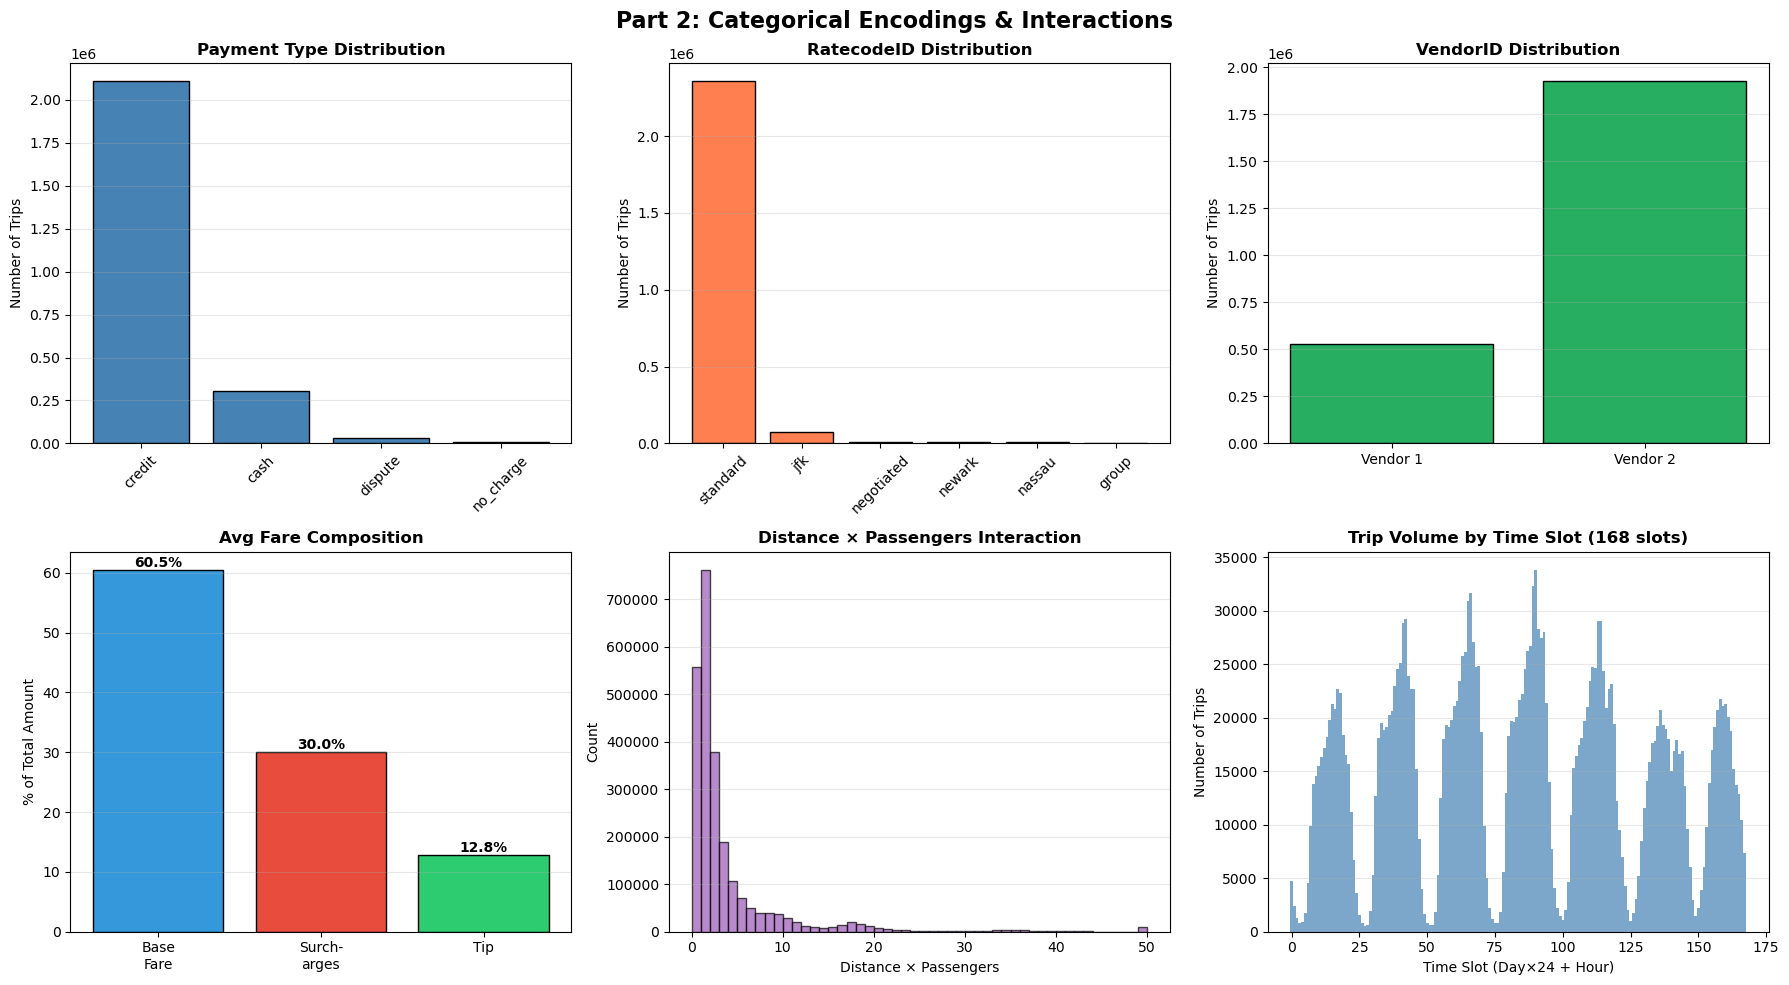


✅ All visualizations complete!


In [13]:
# ============================================================
#        SECTION 6: VERIFICATION & VISUALIZATION
# ============================================================
print("\n" + "="*70)
print("SECTION 6: VERIFICATION & VISUALIZATION")
print("="*70)

# --- 6A: LIST ALL NEW FEATURES ---
feature_summary = {
    'Missing Indicators': [
        'has_missing_passenger_count', 'has_missing_ratecode',
        'has_missing_store_fwd', 'has_missing_congestion_surcharge',
        'has_missing_airport_fee'
    ],
    'Store & Forward': ['store_and_fwd_encoded'],
    'Payment Encoding': list(payment_dummies.columns),
    'Vendor Encoding': list(vendor_dummies.columns),
    'Ratecode Encoding': list(ratecode_dummies.columns),
    'Interaction Features': [
        'distance_x_passengers', 'fare_x_credit', 'fare_x_cash',
        'hour_x_dayofweek', 'time_slot'
    ],
    'Fare Component Ratios': [
        'congestion_surcharge_ratio', 'airport_fee_ratio', 'mta_tax_ratio',
        'cbd_fee_ratio', 'tolls_ratio', 'extra_ratio',
        'total_surcharges', 'surcharges_ratio', 'base_fare_ratio'
    ]
}

total_new = 0
print("\n📋 ALL PART 2 FEATURES BY CATEGORY:")
for category, features in feature_summary.items():
    print(f"\n   {category} ({len(features)} features):")
    for feat in features:
        if feat in df.columns:
            print(f"     ✅ {feat}")
        else:
            print(f"     ❌ {feat} - MISSING!")
    total_new += len(features)

# --- 6B: NaN CHECK ---
print(f"\n🔍 NaN CHECK:")
all_new = [f for feats in feature_summary.values()
           for f in feats if f in df.columns]
numeric_new = [f for f in all_new if df[f].dtype in ['float64', 'int64', 'int32']]
nan_check = df[numeric_new].isnull().sum()
nan_found = nan_check[nan_check > 0]
if len(nan_found) == 0:
    print("   ✅ No NaN values in any new feature!")
else:
    print(f"   ⚠️ NaN values found:")
    print(nan_found)

# --- 6C: DATASET SUMMARY ---
print(f"\n📊 DATASET SUMMARY:")
print(f"   Total trips: {len(df):,}")
print(f"   Columns from Part 1: {original_col_count}")
print(f"   New features in Part 2: {total_new}")
print(f"   Total columns now: {len(df.columns)}")

# --- 6D: VISUALIZATIONS ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Part 2: Categorical Encodings & Interactions', fontsize=16, fontweight='bold')

# 1. Payment type distribution
pay_counts = df['payment_name'].value_counts()
axes[0, 0].bar(pay_counts.index, pay_counts.values, color='steelblue', edgecolor='black')
axes[0, 0].set_ylabel('Number of Trips')
axes[0, 0].set_title('Payment Type Distribution', fontweight='bold')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Ratecode distribution
rate_counts = df['ratecode_name'].value_counts()
axes[0, 1].bar(rate_counts.index, rate_counts.values, color='coral', edgecolor='black')
axes[0, 1].set_ylabel('Number of Trips')
axes[0, 1].set_title('RatecodeID Distribution', fontweight='bold')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. VendorID distribution
vendor_counts = df['VendorID'].value_counts().sort_index()
axes[0, 2].bar([f'Vendor {v}' for v in vendor_counts.index], vendor_counts.values,
               color='#27ae60', edgecolor='black')
axes[0, 2].set_ylabel('Number of Trips')
axes[0, 2].set_title('VendorID Distribution', fontweight='bold')
axes[0, 2].grid(axis='y', alpha=0.3)

# 4. Fare composition (component ratios)
ratio_means = {
    'Base\nFare': df['base_fare_ratio'].mean(),
    'Surch-\narges': df['surcharges_ratio'].mean(),
    'Tip': df['tip_to_total_ratio'].mean() if 'tip_to_total_ratio' in df.columns else 0
}
axes[1, 0].bar(ratio_means.keys(), ratio_means.values(),
               color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
axes[1, 0].set_ylabel('% of Total Amount')
axes[1, 0].set_title('Avg Fare Composition', fontweight='bold')
for i, (k, v) in enumerate(ratio_means.items()):
    axes[1, 0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)

# 5. Distance × Passengers interaction
axes[1, 1].hist(df['distance_x_passengers'].clip(upper=50), bins=50,
                color='#9b59b6', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Distance × Passengers')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Distance × Passengers Interaction', fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

# 6. Time slot heatmap-style bar
hourly_slots = df.groupby('time_slot').size()
axes[1, 2].bar(hourly_slots.index, hourly_slots.values, color='steelblue', alpha=0.7, width=1.0)
axes[1, 2].set_xlabel('Time Slot (Day×24 + Hour)')
axes[1, 2].set_ylabel('Number of Trips')
axes[1, 2].set_title('Trip Volume by Time Slot (168 slots)', fontweight='bold')
axes[1, 2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ All visualizations complete!")

In [14]:
# ============================================================
#                     SECTION 7: SAVE
# ============================================================
print("\n" + "="*70)
print("SECTION 7: SAVING FINAL DATASET")
print("="*70)

output_path = r"C:\Users\hunda\OneDrive\Desktop\Syracuse\Masters\Sem 2\IST 707 Applied Machine Learning\ML\group-project-avengers\data\processed\Morgan_taxi_features_final.parquet"
df.to_parquet(output_path, index=False)

print(f"✅ Final feature-engineered data saved!")
print(f"   Path: {output_path}")
print(f"   Trips: {len(df):,}")
print(f"   Total columns: {len(df.columns)}")

print(f"\n{'='*70}")
print("✅ FEATURE ENGINEERING PART 2 COMPLETE!")
print(f"{'='*70}")
print(f"\nFeatures created in Part 2:")
print(f"   Section 1: 5 missing value indicators")
print(f"   Section 2: store_and_fwd_encoded")
print(f"   Section 3: payment, vendor, ratecode one-hot dummies")
print(f"   Section 4: distance_x_passengers, fare_x_credit,")
print(f"              fare_x_cash, hour_x_dayofweek, time_slot")
print(f"   Section 5: 9 fare component ratios")


SECTION 7: SAVING FINAL DATASET
✅ Final feature-engineered data saved!
   Path: C:\Users\hunda\OneDrive\Desktop\Syracuse\Masters\Sem 2\IST 707 Applied Machine Learning\ML\group-project-avengers\data\processed\Morgan_taxi_features_final.parquet
   Trips: 2,451,103
   Total columns: 68

✅ FEATURE ENGINEERING PART 2 COMPLETE!

Features created in Part 2:
   Section 1: 5 missing value indicators
   Section 2: store_and_fwd_encoded
   Section 3: payment, vendor, ratecode one-hot dummies
   Section 4: distance_x_passengers, fare_x_credit,
              fare_x_cash, hour_x_dayofweek, time_slot
   Section 5: 9 fare component ratios
